In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path
from scipy.sparse import issparse

BASE = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
ATLAS = BASE / "macrophage_annotation" / "Macrophage_Atlas_FINAL_v3_CLEAN_ANNOTATED.h5ad"
OUT = BASE / "circularity_control"
OUT.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(ATLAS)
print(f"Atlas: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
print(f".var columns: {list(adata.var.columns)}")

# Check if HVG flag is already stored
if "highly_variable" in adata.var.columns:
    hvg_set = set(adata.var_names[adata.var["highly_variable"]])
    print(f"\n[HVG flag found in .var] n_HVG = {len(hvg_set):,}")
else:
    print("\n[HVG flag NOT stored — recomputing with pipeline settings]")
    adata_tmp = adata.copy()
    # Normalize + log only if not already done (check .uns or .X scale)
    if adata_tmp.X.max() > 50:  # raw counts
        sc.pp.normalize_total(adata_tmp, target_sum=1e4)
        sc.pp.log1p(adata_tmp)
    sc.pp.highly_variable_genes(
        adata_tmp,
        n_top_genes=5000,
        flavor="seurat",  # default; change to match pipeline if different
        batch_key="dataset" if "dataset" in adata_tmp.obs.columns else None,
    )
    hvg_set = set(adata_tmp.var_names[adata_tmp.var["highly_variable"]])
    print(f"n_HVG recomputed = {len(hvg_set):,}")
    del adata_tmp

non_hvg = [g for g in adata.var_names if g not in hvg_set]
print(f"non-HVG genes (invisible to Scanorama): {len(non_hvg):,}")

# Save HVG set for reference
pd.DataFrame({"gene": sorted(hvg_set)}).to_csv(OUT / "hvg_set.csv", index=False)
pd.DataFrame({"gene": non_hvg}).to_csv(OUT / "non_hvg_set.csv", index=False)
print(f"\nSaved to {OUT}/")

/storage/homefs/sv24v923/.conda/envs/py311_r_env/lib/python3.11/site-packages/scanpy/_utils/__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/storage/homefs/sv24v923/.conda/envs/py311_r_env/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/storage/homefs/sv24v923/.conda/envs/py311_r_env/lib/python3.11/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


Atlas: 81,633 cells x 23,496 genes
.var columns: ['highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection']

[HVG flag found in .var] n_HVG = 3,000
non-HVG genes (invisible to Scanorama): 20,496

Saved to /storage/homefs/sv24v923/MPI_data/clean_pipeline/circularity_control/


In [4]:
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path
from scipy.sparse import issparse

BASE = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
OUT = BASE / "circularity_control"

CT_COL = "cell_type_meta_v3"
CT_MAP = {
    "Mono":   "Monocytes",
    "Scav":   "Scavenging / C1q+ Macrophages",
    "Res":    "Resident / Quiescent Macrophages",
    "Inflam": "Inflammatory Macrophages",
    "Foam":   "Lipid-Stressed / Foam Cells",
    "Fibro":  "Fibrotic / Hypoxic Macrophages",
}

# Reload atlas if adata not in memory
try:
    adata
    print(f"adata in memory: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
except NameError:
    print("Reloading atlas...")
    adata = sc.read_h5ad(
        BASE / "macrophage_annotation" / "Macrophage_Atlas_FINAL_v3_CLEAN_ANNOTATED.h5ad"
    )

# Rebuild HVG set
hvg_set = set(adata.var_names[adata.var["highly_variable"]])
print(f"HVG set: {len(hvg_set):,} genes")

adata in memory: 81,633 cells x 23,496 genes
HVG set: 3,000 genes


In [5]:
import scanpy as sc

# One-vs-rest Wilcoxon per meta-cluster across the whole atlas
# This identifies cluster-characteristic markers, not pairwise DE
if "rank_genes_meta" not in adata.uns:
    print("Running one-vs-rest DE per meta-cluster (takes ~2-5 min)...")
    sc.tl.rank_genes_groups(
        adata,
        groupby=CT_COL,
        method="wilcoxon",
        key_added="rank_genes_meta",
        use_raw=False,          # use .X (log-normalized) to match Scanorama input
        n_genes=adata.n_vars,   # rank ALL genes, filter afterwards
    )
    print("Done.")
else:
    print("rank_genes_meta already computed.")

# --- Precompute per-gene stats across ALL clusters (for specificity scoring) ---
from scipy.sparse import issparse
X = adata.X
ct_vals = adata.obs[CT_COL].values
all_clusters = sorted(adata.obs[CT_COL].unique().tolist())

print("\nPrecomputing per-cluster mean expression...")
cluster_means = {}
cluster_pcts  = {}
for cl in all_clusters:
    mask = ct_vals == cl
    Xm = X[mask]
    if issparse(Xm):
        cluster_means[cl] = np.asarray(Xm.mean(axis=0)).flatten()
        cluster_pcts[cl]  = np.asarray((Xm > 0).mean(axis=0)).flatten()
    else:
        cluster_means[cl] = Xm.mean(axis=0)
        cluster_pcts[cl]  = (Xm > 0).mean(axis=0)
cluster_mean_df = pd.DataFrame(cluster_means, index=adata.var_names)
cluster_pct_df  = pd.DataFrame(cluster_pcts,  index=adata.var_names)
print(f"  mean matrix: {cluster_mean_df.shape}")

# --- Extract non-HVG markers for target clusters of interest ---
TARGETS = {
    "Inflam (Scav→Inflam target)": CT_MAP["Inflam"],
    "Scav   (Fibro→Scav target)":  CT_MAP["Scav"],
}

# Filter thresholds — tune after seeing results
MIN_LOG2FC    = 1.0    # ≥2-fold vs rest
MIN_PCT_CLUST = 0.25   # expressed in ≥25% of cluster cells
MIN_MEAN_CLUST = 0.3   # min log-normalized expression in cluster
MIN_SPECIFICITY = 1.5  # cluster mean ≥1.5× second-highest cluster mean
MAX_PADJ      = 0.01
TOP_N         = 40

all_results = {}

for label, cluster_name in TARGETS.items():
    print(f"\n{'='*75}")
    print(f"  {label}")
    print(f"  cluster = '{cluster_name}'")
    print(f"{'='*75}")

    df = sc.get.rank_genes_groups_df(adata, group=cluster_name, key="rank_genes_meta")
    df["is_hvg"] = df["names"].isin(hvg_set)

    # Per-cluster statistics
    df["mean_in_cluster"] = df["names"].map(cluster_mean_df[cluster_name])
    df["pct_in_cluster"]  = df["names"].map(cluster_pct_df[cluster_name])

    # Specificity: cluster mean vs max mean in any OTHER cluster
    other_clusters = [c for c in all_clusters if c != cluster_name]
    other_max = cluster_mean_df[other_clusters].max(axis=1)
    df["max_in_other_clusters"]  = df["names"].map(other_max)
    df["specificity_ratio"] = (
        (df["mean_in_cluster"] + 0.1) / (df["max_in_other_clusters"] + 0.1)
    )
    # Which cluster is the "runner-up" (for sanity check)
    other_argmax = cluster_mean_df[other_clusters].idxmax(axis=1)
    df["runner_up_cluster"] = df["names"].map(other_argmax)

    # Diagnostic: how many non-HVG markers at progressively stricter filters?
    print(f"\n  Non-HVG markers passing filters:")
    for name, mask in [
        ("padj < 0.01",                       (~df["is_hvg"]) & (df["pvals_adj"] < MAX_PADJ)),
        ("+ log2FC ≥ 1.0",                    (~df["is_hvg"]) & (df["pvals_adj"] < MAX_PADJ) & (df["logfoldchanges"] >= MIN_LOG2FC)),
        ("+ pct ≥ 25%",                       (~df["is_hvg"]) & (df["pvals_adj"] < MAX_PADJ) & (df["logfoldchanges"] >= MIN_LOG2FC) & (df["pct_in_cluster"] >= MIN_PCT_CLUST)),
        ("+ mean ≥ 0.3",                      (~df["is_hvg"]) & (df["pvals_adj"] < MAX_PADJ) & (df["logfoldchanges"] >= MIN_LOG2FC) & (df["pct_in_cluster"] >= MIN_PCT_CLUST) & (df["mean_in_cluster"] >= MIN_MEAN_CLUST)),
        ("+ specificity ≥ 1.5×",              (~df["is_hvg"]) & (df["pvals_adj"] < MAX_PADJ) & (df["logfoldchanges"] >= MIN_LOG2FC) & (df["pct_in_cluster"] >= MIN_PCT_CLUST) & (df["mean_in_cluster"] >= MIN_MEAN_CLUST) & (df["specificity_ratio"] >= MIN_SPECIFICITY)),
    ]:
        print(f"    {name:40s}  {mask.sum():>5}")
    # Final non-HVG marker set
    final_mask = (
        (~df["is_hvg"]) &
        (df["pvals_adj"] < MAX_PADJ) &
        (df["logfoldchanges"] >= MIN_LOG2FC) &
        (df["pct_in_cluster"] >= MIN_PCT_CLUST) &
        (df["mean_in_cluster"] >= MIN_MEAN_CLUST) &
        (df["specificity_ratio"] >= MIN_SPECIFICITY)
    )
    markers = df[final_mask].sort_values("specificity_ratio", ascending=False).head(TOP_N)

    # For comparison: how many HVG markers pass the same filters?
    hvg_mask = (
        (df["is_hvg"]) &
        (df["pvals_adj"] < MAX_PADJ) &
        (df["logfoldchanges"] >= MIN_LOG2FC) &
        (df["pct_in_cluster"] >= MIN_PCT_CLUST) &
        (df["mean_in_cluster"] >= MIN_MEAN_CLUST) &
        (df["specificity_ratio"] >= MIN_SPECIFICITY)
    )
    print(f"\n  HVG markers passing same filters (comparison): {hvg_mask.sum()}")

    print(f"\n  Top {min(TOP_N, len(markers))} non-HVG cluster-characteristic genes")
    print(f"  (sorted by specificity = cluster_mean / max_other_cluster_mean)\n")
    print(f"  {'gene':14s} {'log2FC':>8} {'spec':>7} {'mean':>7} "
          f"{'pct':>7}  {'runner-up':20s}")
    print(f"  {'-'*80}")
    for _, row in markers.iterrows():
        ru = row["runner_up_cluster"]
        ru_short = ru.split("/")[0].strip()[:18]
        print(f"  {row['names']:14s} {row['logfoldchanges']:>+8.2f} "
              f"{row['specificity_ratio']:>7.2f} {row['mean_in_cluster']:>7.2f} "
              f"{row['pct_in_cluster']:>7.1%}  {ru_short:20s}")

    # Save
    safe = cluster_name.replace(' ', '_').replace('/', '_').replace('+','p')
    out_file = OUT / f"non_hvg_markers_{safe}.csv"
    markers.to_csv(out_file, index=False)
    all_results[cluster_name] = markers
    print(f"\n  Saved: {out_file.name}")

Running one-vs-rest DE per meta-cluster (takes ~2-5 min)...
Done.

Precomputing per-cluster mean expression...
  mean matrix: (23496, 6)

  Inflam (Scav→Inflam target)
  cluster = 'Inflammatory Macrophages'

  Non-HVG markers passing filters:
    padj < 0.01                                7787
    + log2FC ≥ 1.0                              883
    + pct ≥ 25%                                 133
    + mean ≥ 0.3                                114
    + specificity ≥ 1.5×                         13

  HVG markers passing same filters (comparison): 42

  Top 13 non-HVG cluster-characteristic genes
  (sorted by specificity = cluster_mean / max_other_cluster_mean)

  gene             log2FC    spec    mean     pct  runner-up           
  --------------------------------------------------------------------------------
  SSPN              +2.58    1.85    0.35   29.5%  Scavenging          
  ENSG00000225889    +1.83    1.82    0.35   31.6%  Scavenging          
  CX3CR1            +2.09    1

In [6]:
TARGETS_EXTRA = {
    "Fibro (Foam→Fibro, Res→Fibro, Inflam→Fibro target)": CT_MAP["Fibro"],
}

for label, cluster_name in TARGETS_EXTRA.items():
    print(f"\n{'='*75}")
    print(f"  {label}")
    print(f"  cluster = '{cluster_name}'")
    print(f"{'='*75}")

    df = sc.get.rank_genes_groups_df(adata, group=cluster_name, key="rank_genes_meta")
    df["is_hvg"] = df["names"].isin(hvg_set)
    df["mean_in_cluster"] = df["names"].map(cluster_mean_df[cluster_name])
    df["pct_in_cluster"]  = df["names"].map(cluster_pct_df[cluster_name])
    other_clusters = [c for c in all_clusters if c != cluster_name]
    other_max = cluster_mean_df[other_clusters].max(axis=1)
    df["max_in_other_clusters"] = df["names"].map(other_max)
    df["specificity_ratio"] = (df["mean_in_cluster"] + 0.1) / (df["max_in_other_clusters"] + 0.1)
    other_argmax = cluster_mean_df[other_clusters].idxmax(axis=1)
    df["runner_up_cluster"] = df["names"].map(other_argmax)

    print(f"\n  Non-HVG markers passing filters:")
    for name, mask in [
        ("padj < 0.01", (~df["is_hvg"]) & (df["pvals_adj"] < 0.01)),
        ("+ log2FC ≥ 1.0", (~df["is_hvg"]) & (df["pvals_adj"] < 0.01) & (df["logfoldchanges"] >= 1.0)),
        ("+ pct ≥ 25%", (~df["is_hvg"]) & (df["pvals_adj"] < 0.01) & (df["logfoldchanges"] >= 1.0) & (df["pct_in_cluster"] >= 0.25)),
        ("+ mean ≥ 0.3", (~df["is_hvg"]) & (df["pvals_adj"] < 0.01) & (df["logfoldchanges"] >= 1.0) & (df["pct_in_cluster"] >= 0.25) & (df["mean_in_cluster"] >= 0.3)),
        ("+ specificity ≥ 1.5×", (~df["is_hvg"]) & (df["pvals_adj"] < 0.01) & (df["logfoldchanges"] >= 1.0) & (df["pct_in_cluster"] >= 0.25) & (df["mean_in_cluster"] >= 0.3) & (df["specificity_ratio"] >= 1.5)),
    ]:
        print(f"    {name:40s}  {mask.sum():>5}")

    final_mask = (
        (~df["is_hvg"]) & (df["pvals_adj"] < 0.01) & (df["logfoldchanges"] >= 1.0)
        & (df["pct_in_cluster"] >= 0.25) & (df["mean_in_cluster"] >= 0.3)
        & (df["specificity_ratio"] >= 1.5)
    )
    markers = df[final_mask].sort_values("specificity_ratio", ascending=False).head(40)
    hvg_count = ((df["is_hvg"]) & (df["pvals_adj"] < 0.01) & (df["logfoldchanges"] >= 1.0)
                 & (df["pct_in_cluster"] >= 0.25) & (df["mean_in_cluster"] >= 0.3)
                 & (df["specificity_ratio"] >= 1.5)).sum()
    print(f"\n  HVG markers passing same filters (comparison): {hvg_count}")
    print(f"\n  Top {min(40, len(markers))} non-HVG cluster-characteristic genes\n")
    print(f"  {'gene':14s} {'log2FC':>8} {'spec':>7} {'mean':>7} {'pct':>7}  {'runner-up':20s}")
    print(f"  {'-'*80}")
    for _, row in markers.iterrows():
        ru_short = str(row["runner_up_cluster"]).split("/")[0].strip()[:18]
        print(f"  {row['names']:14s} {row['logfoldchanges']:>+8.2f} "
              f"{row['specificity_ratio']:>7.2f} {row['mean_in_cluster']:>7.2f} "
              f"{row['pct_in_cluster']:>7.1%}  {ru_short:20s}")

    safe = cluster_name.replace(' ', '_').replace('/', '_').replace('+','p')
    markers.to_csv(OUT / f"non_hvg_markers_{safe}.csv", index=False)


  Fibro (Foam→Fibro, Res→Fibro, Inflam→Fibro target)
  cluster = 'Fibrotic / Hypoxic Macrophages'

  Non-HVG markers passing filters:
    padj < 0.01                                6998
    + log2FC ≥ 1.0                             1239
    + pct ≥ 25%                                 444
    + mean ≥ 0.3                                328
    + specificity ≥ 1.5×                         83

  HVG markers passing same filters (comparison): 19

  Top 40 non-HVG cluster-characteristic genes

  gene             log2FC    spec    mean     pct  runner-up           
  --------------------------------------------------------------------------------
  MATK              +4.25    2.95    0.60   49.7%  Lipid-Stressed      
  KCNN4             +3.13    2.22    0.43   43.6%  Lipid-Stressed      
  NME1              +2.56    2.10    0.84   58.9%  Lipid-Stressed      
  BOLA3             +2.05    2.07    0.47   45.4%  Scavenging          
  ADAM8             +2.11    1.99    0.51   46.8%  Lipid-Stre

In [7]:
TARGETS_REMAINING = {
    "Foam (Mono→Foam target)":     CT_MAP["Foam"],
    "Res  (Mono→Res target)":      CT_MAP["Res"],
}

for label, cluster_name in TARGETS_REMAINING.items():
    print(f"\n{'='*75}")
    print(f"  {label}")
    print(f"  cluster = '{cluster_name}'")
    print(f"{'='*75}")

    df = sc.get.rank_genes_groups_df(adata, group=cluster_name, key="rank_genes_meta")
    df["is_hvg"] = df["names"].isin(hvg_set)
    df["mean_in_cluster"] = df["names"].map(cluster_mean_df[cluster_name])
    df["pct_in_cluster"]  = df["names"].map(cluster_pct_df[cluster_name])
    other_clusters = [c for c in all_clusters if c != cluster_name]
    other_max = cluster_mean_df[other_clusters].max(axis=1)
    df["max_in_other_clusters"] = df["names"].map(other_max)
    df["specificity_ratio"] = (df["mean_in_cluster"] + 0.1) / (df["max_in_other_clusters"] + 0.1)
    other_argmax = cluster_mean_df[other_clusters].idxmax(axis=1)
    df["runner_up_cluster"] = df["names"].map(other_argmax)

    print(f"\n  Non-HVG markers passing filters:")
    for name, mask in [
        ("padj < 0.01", (~df["is_hvg"]) & (df["pvals_adj"] < 0.01)),
        ("+ log2FC ≥ 1.0", (~df["is_hvg"]) & (df["pvals_adj"] < 0.01) & (df["logfoldchanges"] >= 1.0)),
        ("+ pct ≥ 25%", (~df["is_hvg"]) & (df["pvals_adj"] < 0.01) & (df["logfoldchanges"] >= 1.0) & (df["pct_in_cluster"] >= 0.25)),
        ("+ mean ≥ 0.3", (~df["is_hvg"]) & (df["pvals_adj"] < 0.01) & (df["logfoldchanges"] >= 1.0) & (df["pct_in_cluster"] >= 0.25) & (df["mean_in_cluster"] >= 0.3)),
        ("+ specificity ≥ 1.5×", (~df["is_hvg"]) & (df["pvals_adj"] < 0.01) & (df["logfoldchanges"] >= 1.0) & (df["pct_in_cluster"] >= 0.25) & (df["mean_in_cluster"] >= 0.3) & (df["specificity_ratio"] >= 1.5)),
    ]:
        print(f"    {name:40s}  {mask.sum():>5}")

    final_mask = (
        (~df["is_hvg"]) & (df["pvals_adj"] < 0.01) & (df["logfoldchanges"] >= 1.0)
        & (df["pct_in_cluster"] >= 0.25) & (df["mean_in_cluster"] >= 0.3)
        & (df["specificity_ratio"] >= 1.5)
    )
    markers = df[final_mask].sort_values("specificity_ratio", ascending=False).head(40)
    hvg_count = ((df["is_hvg"]) & (df["pvals_adj"] < 0.01) & (df["logfoldchanges"] >= 1.0)
                 & (df["pct_in_cluster"] >= 0.25) & (df["mean_in_cluster"] >= 0.3)
                 & (df["specificity_ratio"] >= 1.5)).sum()
    print(f"\n  HVG markers passing same filters (comparison): {hvg_count}")
    print(f"\n  Top {min(40, len(markers))} non-HVG cluster-characteristic genes\n")
    print(f"  {'gene':14s} {'log2FC':>8} {'spec':>7} {'mean':>7} {'pct':>7}  {'runner-up':20s}")
    print(f"  {'-'*80}")
    for _, row in markers.iterrows():
        ru_short = str(row["runner_up_cluster"]).split("/")[0].strip()[:18]
        print(f"  {row['names']:14s} {row['logfoldchanges']:>+8.2f} "
              f"{row['specificity_ratio']:>7.2f} {row['mean_in_cluster']:>7.2f} "
              f"{row['pct_in_cluster']:>7.1%}  {ru_short:20s}")

    safe = cluster_name.replace(' ', '_').replace('/', '_').replace('+','p')
    markers.to_csv(OUT / f"non_hvg_markers_{safe}.csv", index=False)


  Foam (Mono→Foam target)
  cluster = 'Lipid-Stressed / Foam Cells'

  Non-HVG markers passing filters:
    padj < 0.01                                7197
    + log2FC ≥ 1.0                              290
    + pct ≥ 25%                                 144
    + mean ≥ 0.3                                144
    + specificity ≥ 1.5×                         12

  HVG markers passing same filters (comparison): 27

  Top 12 non-HVG cluster-characteristic genes

  gene             log2FC    spec    mean     pct  runner-up           
  --------------------------------------------------------------------------------
  DHRS9             +3.41    3.02    0.39   29.9%  Fibrotic            
  MGLL              +2.65    2.55    0.85   52.8%  Scavenging          
  TDP2              +1.81    1.77    0.42   32.9%  Fibrotic            
  MMP24OS           +1.59    1.76    0.77   55.3%  Fibrotic            
  BZW1              +1.86    1.75    1.25   72.2%  Fibrotic            
  CLN8-AS1         

Loaded quartile CSV: 21,146 rows
Source cells (Scavenging / C1q+ Macrophages): 21,146

Quartile sizes:
ot_quartile
Q1    5287
Q2    5286
Q3    5286
Q4    5287
Name: count, dtype: int64

  Scav→Inflam: non-HVG Inflam markers across commitment quartiles
  gene             Q1       Q2       Q3       Q4     log2FC   monotonic?
  ------------------------------------------------------------------------------
  CX3CR1        0.175    0.211    0.205    0.185     +0.050           no
  IFIH1         0.204    0.159    0.170    0.199     -0.023           no
  RIPK1         0.302    0.312    0.331    0.405     +0.328          YES
  PLD4          0.128    0.160    0.145    0.132     +0.027           no
  OTUD1         0.216    0.274    0.379    0.459     +0.825          YES
  HEXIM1        0.235    0.272    0.286    0.276     +0.164           no
  B3GNT5        0.442    0.459    0.520    0.544     +0.249          YES
  WDR74         0.187    0.192    0.205    0.242     +0.253          YES
  SSPN    

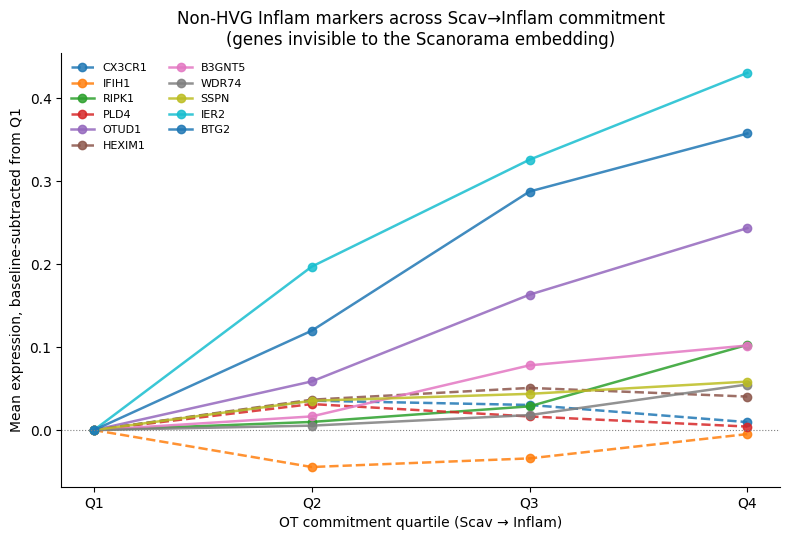


  Saved table: /storage/homefs/sv24v923/MPI_data/clean_pipeline/circularity_control/gradient_nonhvg_Scav_to_Inflam.csv
  Saved plot:  /storage/homefs/sv24v923/MPI_data/clean_pipeline/circularity_control/gradient_nonhvg_Scav_to_Inflam.png


In [8]:
import matplotlib.pyplot as plt

# ---- Curated non-HVG Inflam validators (9 strong + 2 weaker flagged) ----
INFLAM_NONHVG_VALIDATORS = [
    "CX3CR1", "IFIH1", "RIPK1", "PLD4", "OTUD1",
    "HEXIM1", "B3GNT5", "WDR74", "SSPN",
    # weaker — immediate early genes
    "IER2", "BTG2",
]

# ---- Paths ----
GRAD_DIR = BASE / "ot_gradients_v3"
TRANSITION = "Scav_to_Inflam"
SRC_CLUSTER = CT_MAP["Scav"]

# ---- Load pre-computed quartile assignments ----
quart_path = GRAD_DIR / f"{TRANSITION}.csv"
quart = pd.read_csv(quart_path)
print(f"Loaded quartile CSV: {len(quart):,} rows")

# ---- Get source cells in the same order as OT_gradients.py uses ----
src_idx = np.where(adata.obs[CT_COL].values == SRC_CLUSTER)[0]
print(f"Source cells ({SRC_CLUSTER}): {len(src_idx):,}")

assert len(quart) == len(src_idx), (
    f"Row mismatch: quartile CSV has {len(quart)} rows, "
    f"source cluster has {len(src_idx)} cells. Alignment broken."
)

# ---- Extract non-HVG gene expression for source cells ----
present = [g for g in INFLAM_NONHVG_VALIDATORS if g in adata.var_names]
missing = [g for g in INFLAM_NONHVG_VALIDATORS if g not in adata.var_names]
if missing:
    print(f"  WARNING — not in atlas: {missing}")

expr_cols = {}
for gene in present:
    gi = adata.var_names.get_loc(gene)
    col = adata.X[src_idx, gi]
    if hasattr(col, "toarray"):
        col = col.toarray().flatten()
    expr_cols[gene] = np.asarray(col).flatten()
expr = pd.DataFrame(expr_cols)
expr["ot_quartile"] = quart["ot_quartile_corrected"].values

# Sanity-check: all four quartiles present
print(f"\nQuartile sizes:")
print(expr["ot_quartile"].value_counts().sort_index())

# ---- Compute Q1-Q4 means, log2FC, monotonicity ----
print(f"\n{'='*78}")
print(f"  Scav→Inflam: non-HVG Inflam markers across commitment quartiles")
print(f"{'='*78}")
print(f"  {'gene':10s}  {'Q1':>7}  {'Q2':>7}  {'Q3':>7}  {'Q4':>7}   "
      f"{'log2FC':>8}   {'monotonic?':>10}")
print(f"  {'-'*78}")

results = []
for gene in present:
    qm = expr.groupby("ot_quartile")[gene].mean()
    q = [float(qm.get(f"Q{i}", np.nan)) for i in range(1, 5)]
    lfc = np.log2((q[3] + 0.1) / (q[0] + 0.1))
    monotonic = all(q[i] <= q[i+1] for i in range(3))
    weakly_monotonic = (q[3] > q[0]) and (q[3] >= q[2] >= q[1])  # allows Q1=Q2
    flag = "YES" if monotonic else ("~YES" if weakly_monotonic else "no")
    print(f"  {gene:10s}  {q[0]:>7.3f}  {q[1]:>7.3f}  {q[2]:>7.3f}  {q[3]:>7.3f}   "
          f"{lfc:>+8.3f}   {flag:>10s}")
    results.append({
        "gene": gene,
        "Q1": q[0], "Q2": q[1], "Q3": q[2], "Q4": q[3],
        "log2FC_Q4_vs_Q1": lfc,
        "monotonic": monotonic,
        "weakly_monotonic": weakly_monotonic,
    })

results_df = pd.DataFrame(results)
n_mono = int(results_df["monotonic"].sum())
n_weak = int(results_df["weakly_monotonic"].sum())
n_rise = int((results_df["log2FC_Q4_vs_Q1"] > 0.3).sum())
n_total = len(results_df)

print(f"\n  Summary:")
print(f"    {n_mono}/{n_total} genes show strict monotonic rise (Q1<Q2<Q3<Q4)")
print(f"    {n_weak}/{n_total} genes show weakly monotonic rise (allows Q1≈Q2)")
print(f"    {n_rise}/{n_total} genes have log2FC(Q4 vs Q1) > 0.3")

results_df.to_csv(OUT / f"gradient_nonhvg_{TRANSITION}.csv", index=False)

# ---- Plot: one line per gene, Q1→Q4 ----
fig, ax = plt.subplots(figsize=(8, 5.5))
xs = [1, 2, 3, 4]
for _, row in results_df.iterrows():
    style = "-" if row["monotonic"] else "--"
    # baseline-subtract (Q1 = 0) so lines start at same point
    vals = [row[f"Q{i}"] - row["Q1"] for i in range(1, 5)]
    ax.plot(xs, vals, style, marker="o", label=row["gene"], linewidth=1.8, alpha=0.85)

ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
ax.set_xticks(xs)
ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4"])
ax.set_xlabel("OT commitment quartile (Scav → Inflam)")
ax.set_ylabel("Mean expression, baseline-subtracted from Q1")
ax.set_title("Non-HVG Inflam markers across Scav→Inflam commitment\n"
             "(genes invisible to the Scanorama embedding)")
ax.legend(loc="upper left", fontsize=8, ncol=2, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / f"gradient_nonhvg_{TRANSITION}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n  Saved table: {OUT}/gradient_nonhvg_{TRANSITION}.csv")
print(f"  Saved plot:  {OUT}/gradient_nonhvg_{TRANSITION}.png")

Source cells (Scavenging / C1q+ Macrophages): 21,146

  Target-specificity control: same non-HVG genes, same Scav cells,
  ranked by commitment to Inflam vs to Fibro
  gene         log2FC→Inflam   mono    log2FC→Fibro   mono     Δ(I−F)  interpretation
  --------------------------------------------------------------------------------------------
  CX3CR1              +0.050     no          -1.055     no     +1.105  neither
  OTUD1               +0.825    YES          -0.062     no     +0.887  Inflam-specific ✓
  SSPN                +0.353    YES          -0.494     no     +0.847  Inflam-specific ✓
  BTG2                +0.662    YES          -0.159     no     +0.821  Inflam-specific ✓
  B3GNT5              +0.249    YES          -0.521     no     +0.770  ambiguous
  HEXIM1              +0.164     no          -0.493     no     +0.657  ambiguous
  RIPK1               +0.328    YES          -0.310     no     +0.638  Inflam-specific ✓
  IER2                +0.550    YES          -0.074     

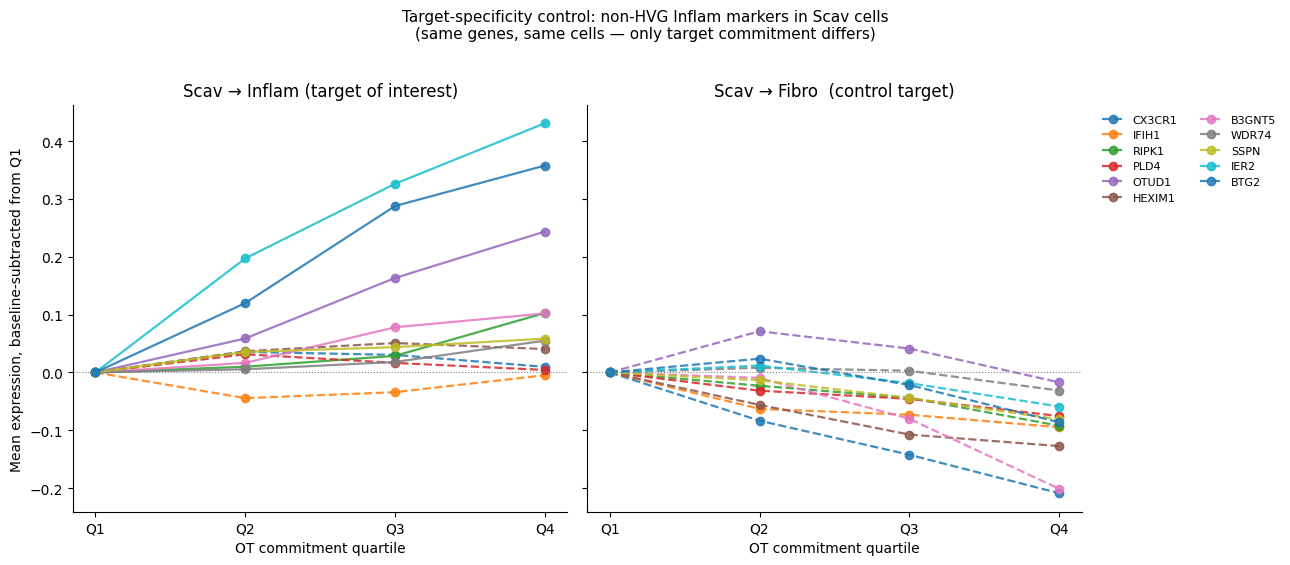


  Saved table: /storage/homefs/sv24v923/MPI_data/clean_pipeline/circularity_control/target_specificity_Scav_Inflam_vs_Fibro.csv
  Saved plot:  /storage/homefs/sv24v923/MPI_data/clean_pipeline/circularity_control/target_specificity_Scav_Inflam_vs_Fibro.png


In [9]:
# ---- Shared inputs ----
SRC_CLUSTER = CT_MAP["Scav"]
INFLAM_NONHVG_VALIDATORS = [
    "CX3CR1", "IFIH1", "RIPK1", "PLD4", "OTUD1",
    "HEXIM1", "B3GNT5", "WDR74", "SSPN",
    "IER2", "BTG2",
]

# ---- Locate Scav cells (same order as OT_gradients.py uses) ----
src_idx = np.where(adata.obs[CT_COL].values == SRC_CLUSTER)[0]
print(f"Source cells ({SRC_CLUSTER}): {len(src_idx):,}")

# ---- Pull non-HVG gene expression once for Scav cells ----
present = [g for g in INFLAM_NONHVG_VALIDATORS if g in adata.var_names]
expr_cols = {}
for gene in present:
    gi = adata.var_names.get_loc(gene)
    col = adata.X[src_idx, gi]
    if hasattr(col, "toarray"):
        col = col.toarray().flatten()
    expr_cols[gene] = np.asarray(col).flatten()
expr_base = pd.DataFrame(expr_cols)

# ---- Load both transitions' commitment quartiles ----
TRANSITIONS_TO_COMPARE = {
    "Scav_to_Inflam": "Scav → Inflam (target of interest)",
    "Scav_to_Fibro":  "Scav → Fibro  (control target)",
}

gradient_tables = {}
for trans_key, _ in TRANSITIONS_TO_COMPARE.items():
    quart_path = GRAD_DIR / f"{trans_key}.csv"
    quart = pd.read_csv(quart_path)
    assert len(quart) == len(src_idx), (
        f"{trans_key}: quartile CSV rows ({len(quart)}) "
        f"!= Scav cells ({len(src_idx)})"
    )
    expr = expr_base.copy()
    expr["ot_quartile"] = quart["ot_quartile_corrected"].values

    rows = []
    for gene in present:
        qm = expr.groupby("ot_quartile")[gene].mean()
        q = [float(qm.get(f"Q{i}", np.nan)) for i in range(1, 5)]
        lfc = np.log2((q[3] + 0.1) / (q[0] + 0.1))
        monotonic = all(q[i] <= q[i+1] for i in range(3))
        rows.append({
            "gene": gene,
            "Q1": q[0], "Q2": q[1], "Q3": q[2], "Q4": q[3],
            "log2FC": lfc,
            "monotonic": monotonic,
        })
    gradient_tables[trans_key] = pd.DataFrame(rows)

# ---- Side-by-side comparison table ----
inflam_df = gradient_tables["Scav_to_Inflam"].set_index("gene")
fibro_df  = gradient_tables["Scav_to_Fibro"].set_index("gene")

comp = pd.DataFrame({
    "Q1_inflam":  inflam_df["Q1"],
    "Q4_inflam":  inflam_df["Q4"],
    "log2FC_inflam": inflam_df["log2FC"],
    "mono_inflam":   inflam_df["monotonic"],
    "Q1_fibro":   fibro_df["Q1"],
    "Q4_fibro":   fibro_df["Q4"],
    "log2FC_fibro":  fibro_df["log2FC"],
    "mono_fibro":    fibro_df["monotonic"],
})
comp["delta_log2FC"] = comp["log2FC_inflam"] - comp["log2FC_fibro"]
comp = comp.sort_values("delta_log2FC", ascending=False)

print(f"\n{'='*92}")
print(f"  Target-specificity control: same non-HVG genes, same Scav cells,")
print(f"  ranked by commitment to Inflam vs to Fibro")
print(f"{'='*92}")
print(f"  {'gene':10s}  "
      f"{'log2FC→Inflam':>14s}  {'mono':>5s}   "
      f"{'log2FC→Fibro':>13s}  {'mono':>5s}   "
      f"{'Δ(I−F)':>8s}  interpretation")
print(f"  {'-'*92}")
for gene, row in comp.iterrows():
    m_i = "YES" if row["mono_inflam"] else "no"
    m_f = "YES" if row["mono_fibro"]  else "no"
    if row["delta_log2FC"] > 0.2 and row["log2FC_inflam"] > 0.3:
        tag = "Inflam-specific ✓"
    elif row["log2FC_inflam"] > 0.3 and row["log2FC_fibro"] > 0.3:
        tag = "both (non-specific)"
    elif row["log2FC_inflam"] < 0.1 and row["log2FC_fibro"] < 0.1:
        tag = "neither"
    elif row["delta_log2FC"] < -0.2:
        tag = "Fibro-biased"
    else:
        tag = "ambiguous"
    print(f"  {gene:10s}  "
          f"{row['log2FC_inflam']:>+14.3f}  {m_i:>5s}   "
          f"{row['log2FC_fibro']:>+13.3f}  {m_f:>5s}   "
          f"{row['delta_log2FC']:>+8.3f}  {tag}")

n_inflam_specific = ((comp["delta_log2FC"] > 0.2) & (comp["log2FC_inflam"] > 0.3)).sum()
n_both = ((comp["log2FC_inflam"] > 0.3) & (comp["log2FC_fibro"] > 0.3)).sum()

print(f"\n  Summary:")
print(f"    Inflam-specific (rises in Inflam, not in Fibro): {n_inflam_specific}/{len(comp)}")
print(f"    Non-specific (rises in both targets):            {n_both}/{len(comp)}")

comp.to_csv(OUT / "target_specificity_Scav_Inflam_vs_Fibro.csv")

# ---- Paired plot: each gene, both targets ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
xs = [1, 2, 3, 4]

for ax, (trans_key, label) in zip(axes, TRANSITIONS_TO_COMPARE.items()):
    tbl = gradient_tables[trans_key].set_index("gene")
    for gene in present:
        vals = [tbl.loc[gene, f"Q{i}"] - tbl.loc[gene, "Q1"] for i in range(1, 5)]
        mono = tbl.loc[gene, "monotonic"]
        style = "-" if mono else "--"
        ax.plot(xs, vals, style, marker="o", label=gene, linewidth=1.6, alpha=0.85)
    ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
    ax.set_xticks(xs)
    ax.set_xticklabels(["Q1", "Q2", "Q3", "Q4"])
    ax.set_xlabel("OT commitment quartile")
    ax.set_title(label)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Mean expression, baseline-subtracted from Q1")
axes[1].legend(loc="upper left", fontsize=8, ncol=2, frameon=False,
               bbox_to_anchor=(1.02, 1.0))
fig.suptitle("Target-specificity control: non-HVG Inflam markers in Scav cells\n"
             "(same genes, same cells — only target commitment differs)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(OUT / "target_specificity_Scav_Inflam_vs_Fibro.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\n  Saved table: {OUT}/target_specificity_Scav_Inflam_vs_Fibro.csv")
print(f"  Saved plot:  {OUT}/target_specificity_Scav_Inflam_vs_Fibro.png")

  Inflam: 13 validators — ['SSPN', 'ENSG00000225889', 'CX3CR1', 'THUMPD3-AS1', 'IFIH1']...
  Fibro: 15 validators — ['MATK', 'KCNN4', 'NME1', 'BOLA3', 'ADAM8']...
  Foam: 12 validators — ['DHRS9', 'MGLL', 'TDP2', 'MMP24OS', 'BZW1']...

  Layering (Scav→Inflam vs Scav→Fibro)
  Source: Scavenging / C1q+ Macrophages
  Validators: non-HVG markers of Inflammatory Macrophages (target of interest)
  Control:    commitment to Fibrotic / Hypoxic Macrophages (wrong target)
  Source cells: 21,146
  gene           log2FC→Inflam  mono     log2FC→Fibro  mono          Δ  tag
  --------------------------------------------------------------------------------------------
  CX3CR1                +0.050    no           -1.055    no     +1.105  neither
  OTUD1                 +0.825   YES           -0.062    no     +0.887  Inflam-specific ✓
  SSPN                  +0.353   YES           -0.494    no     +0.847  Inflam-specific ✓
  BTG2                  +0.662   YES           -0.159    no     +0.821  Inflam

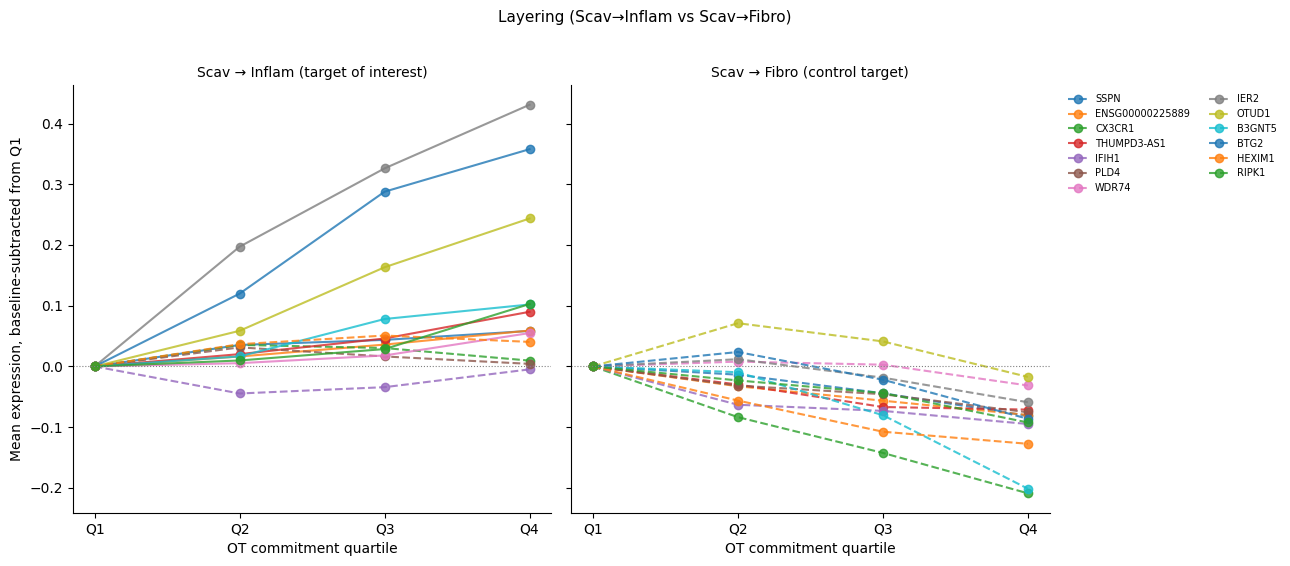


  Reconfiguration A (Mono→Inflam vs Mono→Foam)
  Source: Monocytes
  Validators: non-HVG markers of Inflammatory Macrophages (target of interest)
  Control:    commitment to Lipid-Stressed / Foam Cells (wrong target)
  Source cells: 20,449
  gene           log2FC→Inflam  mono      log2FC→Foam  mono          Δ  tag
  --------------------------------------------------------------------------------------------
  ENSG00000225889          +0.777   YES           -0.933    no     +1.711  Inflam-specific ✓
  B3GNT5                +0.894   YES           -0.807    no     +1.701  Inflam-specific ✓
  BTG2                  +0.570    no           -0.711    no     +1.281  Inflam-specific ✓
  OTUD1                 +0.743   YES           -0.526    no     +1.268  Inflam-specific ✓
  IER2                  +0.418   YES           -0.804    no     +1.222  Inflam-specific ✓
  IFIH1                 +0.503    no           -0.698    no     +1.201  Inflam-specific ✓
  HEXIM1                +0.595   YES         

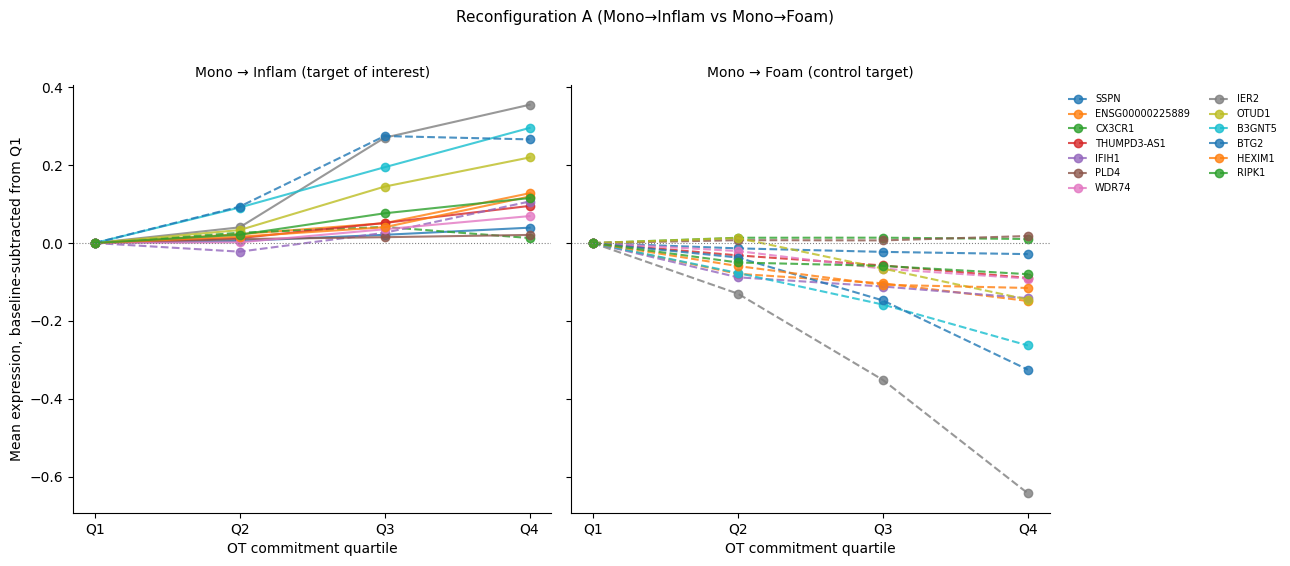


  Reconfiguration B (Mono→Foam vs Mono→Inflam)
  Source: Monocytes
  Validators: non-HVG markers of Lipid-Stressed / Foam Cells (target of interest)
  Control:    commitment to Inflammatory Macrophages (wrong target)
  Source cells: 20,449
  gene             log2FC→Foam  mono    log2FC→Inflam  mono          Δ  tag
  --------------------------------------------------------------------------------------------
  MGLL                  +0.911    no           +0.064    no     +0.847  Foam-specific ✓
  DHRS9                 +0.571   YES           -0.081    no     +0.652  Foam-specific ✓
  SERTAD3               +0.521   YES           -0.066    no     +0.587  Foam-specific ✓
  LYSET                 +0.390   YES           -0.079    no     +0.470  Foam-specific ✓
  NINJ1                 +0.402   YES           +0.061    no     +0.340  Foam-specific ✓
  TDP2                  +0.102    no           -0.152    no     +0.254  ambiguous
  MMP24OS               +0.262   YES           +0.013    no     +0

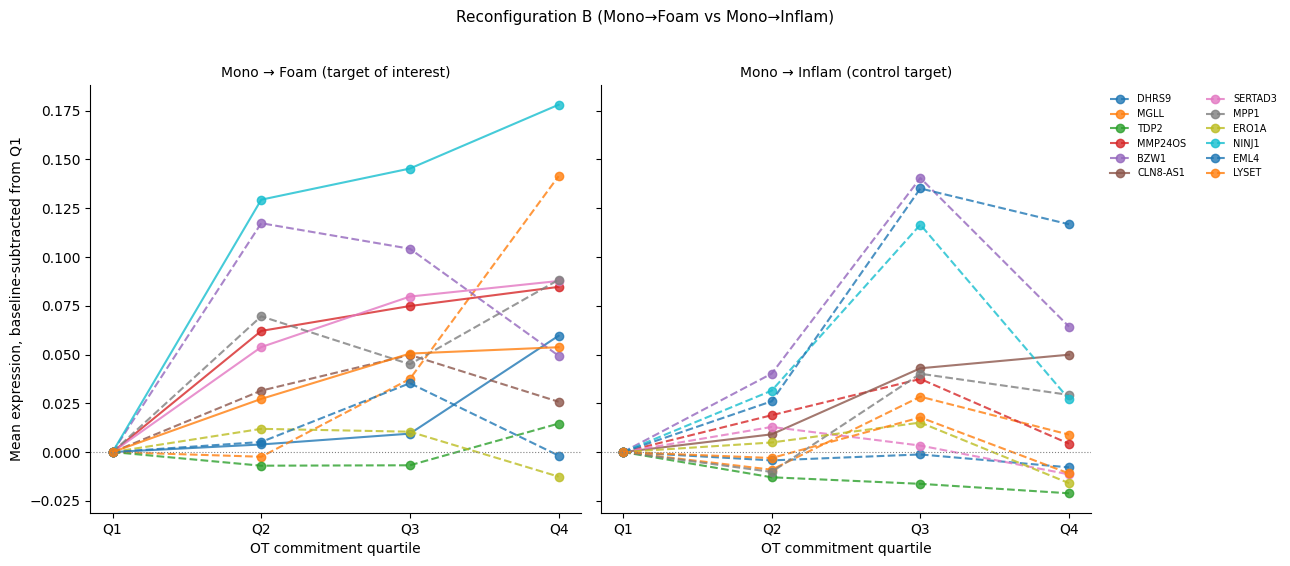


  Mono→Inflam vs Mono→Fibro
  Source: Monocytes
  Validators: non-HVG markers of Inflammatory Macrophages (target of interest)
  Control:    commitment to Fibrotic / Hypoxic Macrophages (wrong target)
  Source cells: 20,449
  gene           log2FC→Inflam  mono     log2FC→Fibro  mono          Δ  tag
  --------------------------------------------------------------------------------------------
  B3GNT5                +0.894   YES           -0.899    no     +1.793  Inflam-specific ✓
  ENSG00000225889          +0.777   YES           -0.743    no     +1.520  Inflam-specific ✓
  IFIH1                 +0.503    no           -0.806    no     +1.309  Inflam-specific ✓
  OTUD1                 +0.743   YES           -0.353    no     +1.095  Inflam-specific ✓
  HEXIM1                +0.595   YES           -0.492    no     +1.086  Inflam-specific ✓
  BTG2                  +0.570    no           -0.401    no     +0.971  Inflam-specific ✓
  RIPK1                 +0.463   YES           -0.410    no  

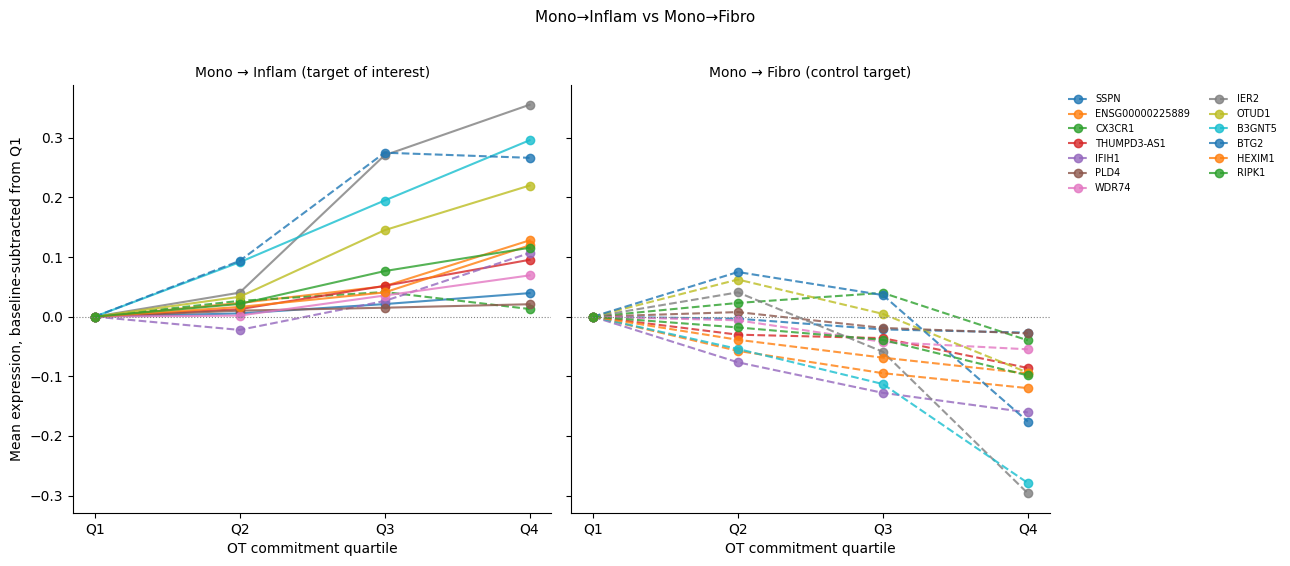


  Mono→Foam vs Mono→Fibro
  Source: Monocytes
  Validators: non-HVG markers of Lipid-Stressed / Foam Cells (target of interest)
  Control:    commitment to Fibrotic / Hypoxic Macrophages (wrong target)
  Source cells: 20,449
  gene             log2FC→Foam  mono     log2FC→Fibro  mono          Δ  tag
  --------------------------------------------------------------------------------------------
  MGLL                  +0.911    no           +0.121    no     +0.790  Foam-specific ✓
  DHRS9                 +0.571   YES           +0.048    no     +0.523  Foam-specific ✓
  EML4                  -0.004    no           -0.256    no     +0.252  neither
  SERTAD3               +0.521   YES           +0.343   YES     +0.178  both
  MPP1                  +0.270    no           +0.181    no     +0.089  ambiguous
  TDP2                  +0.102    no           +0.029    no     +0.073  ambiguous
  CLN8-AS1              +0.143    no           +0.083    no     +0.060  ambiguous
  BZW1                  

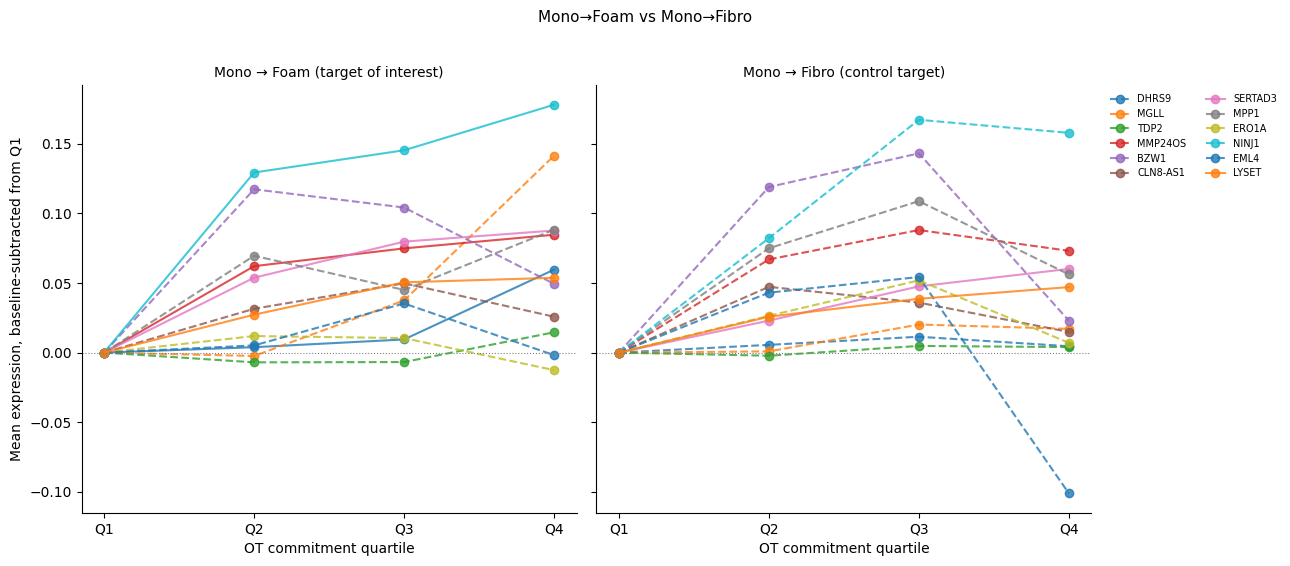


  Layering vs erosion (Res→Inflam vs Res→Fibro)
  Source: Resident / Quiescent Macrophages
  Validators: non-HVG markers of Inflammatory Macrophages (target of interest)
  Control:    commitment to Fibrotic / Hypoxic Macrophages (wrong target)
  Source cells: 10,685
  gene           log2FC→Inflam  mono     log2FC→Fibro  mono          Δ  tag
  --------------------------------------------------------------------------------------------
  B3GNT5                +1.038    no           -0.913    no     +1.951  Inflam-specific ✓
  BTG2                  +1.250   YES           -0.630    no     +1.880  Inflam-specific ✓
  ENSG00000225889          +1.005   YES           -0.787    no     +1.793  Inflam-specific ✓
  OTUD1                 +0.983   YES           -0.573    no     +1.556  Inflam-specific ✓
  IER2                  +0.913   YES           -0.476    no     +1.389  Inflam-specific ✓
  THUMPD3-AS1           +0.644   YES           -0.732    no     +1.376  Inflam-specific ✓
  RIPK1           

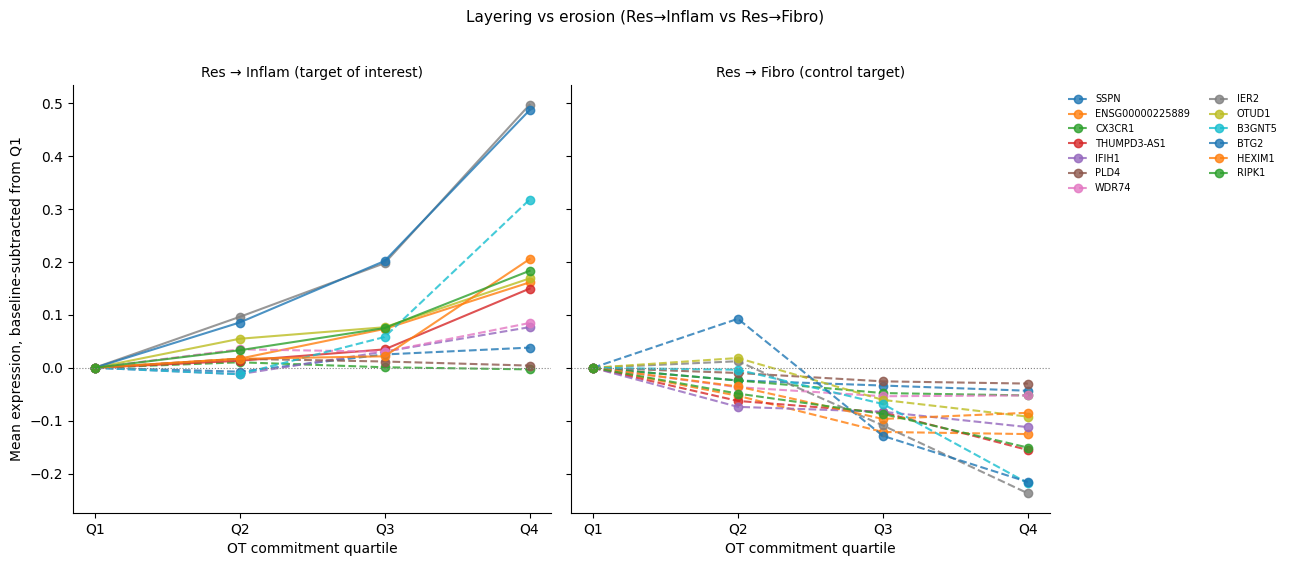


  Dominant fibrotic route (Foam→Fibro vs Foam→Inflam)
  Source: Lipid-Stressed / Foam Cells
  Validators: non-HVG markers of Fibrotic / Hypoxic Macrophages (target of interest)
  Control:    commitment to Inflammatory Macrophages (wrong target)
  Source cells: 8,962
  SKIP — missing CSV (Foam_to_Fibro.csv or Foam_to_Inflam.csv)

  Inflam→Fibro vs Inflam→Foam
  Source: Inflammatory Macrophages
  Validators: non-HVG markers of Fibrotic / Hypoxic Macrophages (target of interest)
  Control:    commitment to Lipid-Stressed / Foam Cells (wrong target)
  Source cells: 14,907
  SKIP — missing CSV (Inflam_to_Fibro.csv or Inflam_to_Foam.csv)


  MASTER SUMMARY — target-specificity control across transitions
  comparison                                         specific   both    Δ>0   total
  --------------------------------------------------------------------------------------------
  Scav→Inflam vs Scav→Fibro                                 7      0     13      13
  Mono→Inflam vs Mono→Foam   

In [10]:
import matplotlib.pyplot as plt

# ---- Non-HVG validator lists per target cluster ----
# (re-load from CSVs saved in Cell 2 to stay in sync; top N by specificity)
def load_validators(target_short, top_n=15):
    cluster = CT_MAP[target_short]
    safe = cluster.replace(' ', '_').replace('/', '_').replace('+','p')
    path = OUT / f"non_hvg_markers_{safe}.csv"
    if not path.exists():
        return []
    df = pd.read_csv(path)
    if df.empty:
        return []
    return df.sort_values("specificity_ratio", ascending=False)["names"].head(top_n).tolist()

VALIDATORS = {
    "Inflam": load_validators("Inflam", top_n=15),
    "Fibro":  load_validators("Fibro",  top_n=15),
    "Foam":   load_validators("Foam",   top_n=15),
    # Scav and Res have 0 candidates → skip
}
for tgt, genes in VALIDATORS.items():
    print(f"  {tgt}: {len(genes)} validators — {genes[:5]}...")

# ---- Head-to-head design: source, target_of_interest, control_target ----
# Each row = one comparison: does commitment TO the target raise non-HVG target genes
# MORE than commitment to a different target within the same source pool?
HEAD_TO_HEADS = [
    # Layering case — already validated for Scav→Inflam; included for completeness
    ("Scav",   "Inflam", "Fibro",  "Layering (Scav→Inflam vs Scav→Fibro)"),
    # Reconfiguration cases (Mono source)
    ("Mono",   "Inflam", "Foam",   "Reconfiguration A (Mono→Inflam vs Mono→Foam)"),
    ("Mono",   "Foam",   "Inflam", "Reconfiguration B (Mono→Foam vs Mono→Inflam)"),
    ("Mono",   "Inflam", "Fibro",  "Mono→Inflam vs Mono→Fibro"),
    ("Mono",   "Foam",   "Fibro",  "Mono→Foam vs Mono→Fibro"),
    # Tissue-resident layering — Res→Inflam (layering) vs Res→Fibro (erosion)
    ("Res",    "Inflam", "Fibro",  "Layering vs erosion (Res→Inflam vs Res→Fibro)"),
    # Foam-driven fibrosis — dominant route in Axis C
    ("Foam",   "Fibro",  "Inflam", "Dominant fibrotic route (Foam→Fibro vs Foam→Inflam)"),
    # Inflam→Fibro (attenuation) — uses Fibro validators
    ("Inflam", "Fibro",  "Foam",   "Inflam→Fibro vs Inflam→Foam"),
]

def compute_gradient(src_idx, gene_list, quart_series):
    """Returns DataFrame with Q1-Q4 means, log2FC, monotonicity per gene."""
    present = [g for g in gene_list if g in adata.var_names]
    expr_cols = {}
    for gene in present:
        gi = adata.var_names.get_loc(gene)
        col = adata.X[src_idx, gi]
        if hasattr(col, "toarray"):
            col = col.toarray().flatten()
        expr_cols[gene] = np.asarray(col).flatten()
    expr = pd.DataFrame(expr_cols)
    expr["ot_quartile"] = quart_series.values

    rows = []
    for gene in present:
        qm = expr.groupby("ot_quartile")[gene].mean()
        q = [float(qm.get(f"Q{i}", np.nan)) for i in range(1, 5)]
        lfc = np.log2((q[3] + 0.1) / (q[0] + 0.1))
        mono = all(q[i] <= q[i+1] for i in range(3))
        rows.append({
            "gene": gene,
            "Q1": q[0], "Q2": q[1], "Q3": q[2], "Q4": q[3],
            "log2FC": lfc, "monotonic": mono,
        })
    return pd.DataFrame(rows).set_index("gene")

def run_head_to_head(src_short, tgt_short, ctrl_short, title_text):
    """Run one specificity control, print summary, return comparison DataFrame."""
    print(f"\n{'='*92}")
    print(f"  {title_text}")
    print(f"  Source: {CT_MAP[src_short]}")
    print(f"  Validators: non-HVG markers of {CT_MAP[tgt_short]} (target of interest)")
    print(f"  Control:    commitment to {CT_MAP[ctrl_short]} (wrong target)")
    print(f"{'='*92}")

    gene_list = VALIDATORS.get(tgt_short, [])
    if not gene_list:
        print(f"  SKIP — no non-HVG validators for target '{tgt_short}'")
        return None

    src_idx = np.where(adata.obs[CT_COL].values == CT_MAP[src_short])[0]
    print(f"  Source cells: {len(src_idx):,}")

    # Load both transitions
    key_interest = f"{src_short}_to_{tgt_short}"
    key_control  = f"{src_short}_to_{ctrl_short}"
    path_i = GRAD_DIR / f"{key_interest}.csv"
    path_c = GRAD_DIR / f"{key_control}.csv"
    if not path_i.exists() or not path_c.exists():
        print(f"  SKIP — missing CSV ({path_i.name} or {path_c.name})")
        return None

    quart_i = pd.read_csv(path_i)["ot_quartile_corrected"]
    quart_c = pd.read_csv(path_c)["ot_quartile_corrected"]
    if len(quart_i) != len(src_idx) or len(quart_c) != len(src_idx):
        print(f"  SKIP — row alignment mismatch")
        return None

    grad_i = compute_gradient(src_idx, gene_list, quart_i)
    grad_c = compute_gradient(src_idx, gene_list, quart_c)

    comp = pd.DataFrame({
        "log2FC_interest":  grad_i["log2FC"],
        "mono_interest":    grad_i["monotonic"],
        "log2FC_control":   grad_c["log2FC"],
        "mono_control":     grad_c["monotonic"],
    })
    comp["delta"] = comp["log2FC_interest"] - comp["log2FC_control"]
    comp = comp.sort_values("delta", ascending=False)

    # Print table
    print(f"  {'gene':12s}  {'log2FC→'+tgt_short:>14s}  mono   "
          f"{'log2FC→'+ctrl_short:>14s}  mono   {'Δ':>8s}  tag")
    print(f"  {'-'*92}")
    n_specific = 0
    n_both     = 0
    n_total    = len(comp)
    for gene, row in comp.iterrows():
        m_i = "YES" if row["mono_interest"] else "no"
        m_c = "YES" if row["mono_control"]  else "no"
        if row["delta"] > 0.2 and row["log2FC_interest"] > 0.3:
            tag = f"{tgt_short}-specific ✓"
            n_specific += 1
        elif row["log2FC_interest"] > 0.3 and row["log2FC_control"] > 0.3:
            tag = "both"
            n_both += 1
        elif row["log2FC_interest"] < 0.1 and row["log2FC_control"] < 0.1:
            tag = "neither"
        elif row["delta"] < -0.2:
            tag = f"{ctrl_short}-biased"
        else:
            tag = "ambiguous"
        print(f"  {gene:12s}  "
              f"{row['log2FC_interest']:>+14.3f}  {m_i:>4s}   "
              f"{row['log2FC_control']:>+14.3f}  {m_c:>4s}   "
              f"{row['delta']:>+8.3f}  {tag}")

    n_dir_correct = int((comp["delta"] > 0).sum())
    print(f"\n  Summary:")
    print(f"    {tgt_short}-specific (strong): {n_specific}/{n_total}")
    print(f"    Both-target (non-specific):    {n_both}/{n_total}")
    print(f"    Directionally correct (Δ>0):   {n_dir_correct}/{n_total}")

    # Save
    tag_out = f"{src_short}_{tgt_short}_vs_{ctrl_short}"
    comp.to_csv(OUT / f"specificity_{tag_out}.csv")

    # Paired plot
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
    xs = [1, 2, 3, 4]
    for ax, grad, label, target_tag in [
        (axes[0], grad_i, f"{src_short} → {tgt_short} (target of interest)", tgt_short),
        (axes[1], grad_c, f"{src_short} → {ctrl_short} (control target)",    ctrl_short),
    ]:
        for gene in grad.index:
            vals = [grad.loc[gene, f"Q{i}"] - grad.loc[gene, "Q1"] for i in range(1, 5)]
            mono = grad.loc[gene, "monotonic"]
            style = "-" if mono else "--"
            ax.plot(xs, vals, style, marker="o", label=gene, linewidth=1.5, alpha=0.8)
        ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
        ax.set_xticks(xs); ax.set_xticklabels(["Q1","Q2","Q3","Q4"])
        ax.set_xlabel("OT commitment quartile")
        ax.set_title(label, fontsize=10)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    axes[0].set_ylabel("Mean expression, baseline-subtracted from Q1")
    axes[1].legend(loc="upper left", fontsize=7, ncol=2, frameon=False,
                   bbox_to_anchor=(1.02, 1.0))
    fig.suptitle(title_text, fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(OUT / f"specificity_{tag_out}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return {
        "title": title_text,
        "src": src_short, "tgt": tgt_short, "ctrl": ctrl_short,
        "n_total": n_total, "n_specific": n_specific, "n_both": n_both,
        "n_dir_correct": n_dir_correct,
    }

# ---- Run all ----
all_results = []
for src, tgt, ctrl, title in HEAD_TO_HEADS:
    res = run_head_to_head(src, tgt, ctrl, title)
    if res is not None:
        all_results.append(res)

# ---- Final summary table ----
if all_results:
    summary = pd.DataFrame(all_results)
    print(f"\n\n{'='*92}")
    print(f"  MASTER SUMMARY — target-specificity control across transitions")
    print(f"{'='*92}")
    print(f"  {'comparison':48s}  {'specific':>9s}  {'both':>5s}  {'Δ>0':>5s}  {'total':>6s}")
    print(f"  {'-'*92}")
    for _, r in summary.iterrows():
        label = f"{r['src']}→{r['tgt']} vs {r['src']}→{r['ctrl']}"
        print(f"  {label:48s}  {r['n_specific']:>9d}  {r['n_both']:>5d}  "
              f"{r['n_dir_correct']:>5d}  {r['n_total']:>6d}")
    summary.to_csv(OUT / "specificity_master_summary.csv", index=False)
    print(f"\n  Saved master summary: {OUT}/specificity_master_summary.csv")